In [1]:
import matplotlib.pylab as plt
import numpy as np
import tidy3d as td
import tidy3d.plugins.invdes as tdi
import tidy3d.web as web

## Simulation Region Setup

In [2]:
## Simulation Region Setup
# --- 1. Source and Material Info ---
wavelength = 0.729
freq0 = td.C_0 / wavelength

# Material (Si3N4)
eps_mat = 6.3
medium = td.Medium(permittivity=eps_mat)

# Material (SiO2 Substrate)
eps_sub = 1.45**2  # ~2.1025
medium_sub = td.Medium(permittivity=eps_sub)

In [3]:
# --- 2. Geometric Parameters ---
# Waveguide cross-section
ly_wg = 0.5 * wavelength
lz_wg = 0.3 * wavelength
angle_deg = 6.0

# Define explicit Waveguide Length
wg_length = 6 * wavelength 

# Buffers / Gaps
safety_gap = 0.6 * wavelength 

# *** NEW: Vertical Stack Parameters ***
h_sub = 1.0 * wavelength       # Thickness of SiO2 layer
buffer_top = 1.0 * wavelength  # Adjustable space above the waveguides

# Design region size
lx_des = 8 * wavelength
ly_des = 8 * wavelength
lz_des = 0.3 * wavelength

In [4]:
# --- 3. Calculating Coordinates & Simulation Domain ---

x_wg_end = -lx_des/2 + 1.0 
x_wg_start = x_wg_end - wg_length
dr_center_x = x_wg_end + lx_des / 2

sim_x_min = x_wg_start - safety_gap
sim_x_max = (dr_center_x + lx_des / 2) + safety_gap

# Calculate Size and Center
Lx = sim_x_max - sim_x_min
Ly = ly_des + 2 * safety_gap

# *** NEW: Z-Dimension Calculation ***
# We want the substrate from -h_sub to 0.
# We want the device from 0 to lz_wg (assuming lz_wg >= lz_des).
# We want the top buffer from lz_wg to lz_wg + buffer_top.

z_min = -h_sub
z_max = max(lz_wg, lz_des) + buffer_top

Lz = z_max - z_min
z_center = (z_max + z_min) / 2

# The simulation center is the midpoint of the bounds
sim_center = ((sim_x_min + sim_x_max) / 2, 0, z_center)

# Grid specification
min_steps_per_wvl = 30
pixel_size = wavelength / min_steps_per_wvl / np.sqrt(eps_mat)
grid_spec = td.GridSpec.auto(wavelength=wavelength, min_steps_per_wvl=min_steps_per_wvl)

In [5]:
# --- 4. Defining Structures ---

# A. Substrate
substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin = (-500, -500, -500),
        rmax=(500, 500, 0),
    ),
    medium=medium_sub,
    name="substrate"
)

# B. Angled Input Waveguides
input_waveguides = [substrate] # Start list with substrate
angles = [-angle_deg, 0, angle_deg]

for angle in angles:
    rad = np.radians(angle)
    y_start = x_wg_start * np.tan(rad)
    y_end = x_wg_end * np.tan(rad)
    dx = -np.sin(rad) * (ly_wg / 2)
    dy = np.cos(rad) * (ly_wg / 2)
    
    vertices = [
        (x_wg_start + dx, y_start + dy),
        (x_wg_end + dx,   y_end + dy),
        (x_wg_end - dx,   y_end - dy),
        (x_wg_start - dx, y_start - dy)
    ]
    
    wg = td.Structure(
        geometry=td.PolySlab(
            vertices=vertices,
            # *** UPDATED: Slab bounds are now (0, lz_wg) to sit on substrate ***
            slab_bounds=(0, lz_wg), 
            axis=2,
        ),
        medium=medium,
        name=f"input_wg_{angle}deg"
    )
    input_waveguides.append(wg)

In [6]:
# --- 5. Sources
source_list = []
source_x_pos = x_wg_start + 0.5 * wavelength
# *** UPDATED: Source center Z must shift to lz_wg / 2 ***
source_z_center = lz_wg / 2

for angle in angles:
    rad = np.radians(angle)
    source_y_pos = source_x_pos * np.tan(rad)
    
    # Source at each of the waveguides
    ms = td.ModeSource(
        center=(source_x_pos, source_y_pos, source_z_center),
        size=(0, 2*ly_wg, 4*lz_wg), # Increased size to capture mode tails
        source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0/10),
        direction="+",
        mode_spec=td.ModeSpec(num_modes=1, angle_theta=rad),
        mode_index=0,
        name=f"source_{angle}deg"
    )
    source_list.append(ms)


In [7]:
# --- 5.5 Monitors

# Field Monitor (XY plane at Z = lz_wg/2, inside the device)
field_mnt = td.FieldMonitor(
    center=(sim_center[0], sim_center[1], source_z_center),
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name="field_xy"
)

# Field monitors for each output spot (don't know exactly where they should go tbh)
output_monitors = []
output_x_pos = x_wg_end + lx_des/2
output_y_max = 2.0
num_output_monitors = 3
output_y_positions = np.linspace(-output_y_max, output_y_max, num_output_monitors)

#mode spec
mode_spec = td.ModeSpec(num_modes=1)

for i, y_position in zip(range(num_output_monitors), output_y_positions):
    output_monitor = td.ModeMonitor(
        center = (output_x_pos, y_position, buffer_top),
        size = (wavelength, wavelength, 0),
        freqs=[freq0],
        name=f"output_monitor{i}",
        mode_spec=mode_spec,
    )
    output_monitors.append(output_monitor)



In [8]:
#This is the farfield functionality, it is disabled for now
"""
# Field monitor placed one wavelength above GC to be used as far field interpolator
monitor_near = td.FieldMonitor(
    center = (sim_center[0], sim_center[1], buffer_top),
    size = (td.inf, td.inf, 0),
    freqs = [freq0],
    name="monitor_near"
)

# radial distance away from the origin at which to project fields
r_proj = 50 * wavelength

# theta and phi angles at which to observe fields - part of the half-space to the right
theta_proj = np.linspace(np.pi / 10, np.pi - np.pi / 10, 100)
phi_proj = np.linspace(np.pi / 10, np.pi - np.pi / 10, 100)

# far field projection monitor
monitor_far = td.FieldProjectionAngleMonitor(
    center=[
        0,
        0,
        buffer_top,
    ],  # the monitor's center defined the local origin - the projection distance
    # and angles will all be measured with respect to this local origin
    size=[td.inf, td.inf, 0],
    # the size and center of any far field monitor should indicate where the *near* fields are recorded
    freqs=[freq0],
    name="far_field",
    phi=list(phi_proj),
    theta=list(theta_proj),
    proj_distance=r_proj,
    far_field_approx=True,  # we leave this to its default value of 'True' because we are interested in fields sufficiently
    # far away that geometric far field approximations can be invoked to speed up the calculation
)

# helper function to call the projector
def get_proj_fields(sim_data, monitor_near, monitor_far, pts_per_wavelength=10):
    # object that does projections is constructed using the near-field monitor, because those are the fields to be projected
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=sim_data,
        near_monitors=[monitor_near],
        normal_dirs=["+"],  # we are projecting along the + direction
        pts_per_wavelength=pts_per_wavelength,  # to speed up calculations, the fields on the near-field monitor can be downsampled to these
        # many points per wavelength (default is already 10)
    )
    return projector.project_fields(monitor_far)
"""

'\n# Field monitor placed one wavelength above GC to be used as far field interpolator\nmonitor_near = td.FieldMonitor(\n    center = (sim_center[0], sim_center[1], buffer_top),\n    size = (td.inf, td.inf, 0),\n    freqs = [freq0],\n    name="monitor_near"\n)\n\n# radial distance away from the origin at which to project fields\nr_proj = 50 * wavelength\n\n# theta and phi angles at which to observe fields - part of the half-space to the right\ntheta_proj = np.linspace(np.pi / 10, np.pi - np.pi / 10, 100)\nphi_proj = np.linspace(np.pi / 10, np.pi - np.pi / 10, 100)\n\n# far field projection monitor\nmonitor_far = td.FieldProjectionAngleMonitor(\n    center=[\n        0,\n        0,\n        buffer_top,\n    ],  # the monitor\'s center defined the local origin - the projection distance\n    # and angles will all be measured with respect to this local origin\n    size=[td.inf, td.inf, 0],\n    # the size and center of any far field monitor should indicate where the *near* fields are recor

In [9]:
# --- 6. Simulation Object ---
sim = td.Simulation(
    center=sim_center, 
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    structures=input_waveguides,
    sources=source_list,
    monitors=[field_mnt] + output_monitors,
    run_time=100 / (freq0 / 10), 
    # PML on all sides (Z-min will absorb substrate radiation)
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML())
)

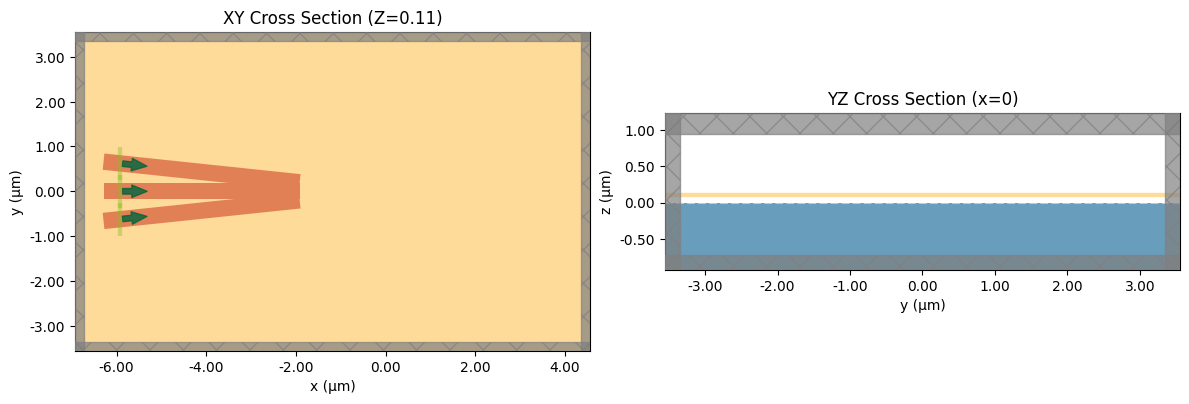

In [10]:
# --- 7. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot XY plane inside the waveguide
sim.plot(z=lz_wg/2, ax=ax1)
ax1.set_title(f"XY Cross Section (Z={lz_wg/2:.2f})")

# Plot YZ Transverse plane to verify stack
# We plot at x = 0 (center of sim) to see the substrate and air
sim.plot(x=0, ax=ax2)
ax2.set_title("YZ Cross Section (x=0)")
# Add horizontal line to show interface
ax2.axhline(0, color='white', linestyle='--', alpha=0.5, label="Interface")

plt.tight_layout()
plt.show()

## Design Region Placeholder

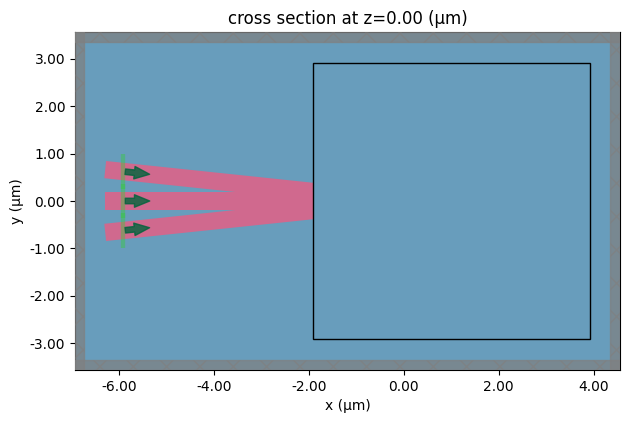

In [11]:
ax = sim.plot(z=0)

import matplotlib

rect = matplotlib.patches.Rectangle(
    xy=(x_wg_end, -ly_des / 2), width=lx_des, height=ly_des, fill=None
)
ax.add_patch(rect)
plt.show()

## Defining Design Region

In [12]:
## --- Inverse Design Region Setup --- 
# (Relevant updates for Z-alignment)

projection_radius = 0.120
beta = 10.0
filter_project = tdi.FilterProject(radius=projection_radius, beta=beta)
length_scale = 0.120
weight = 0.6
penalty = tdi.ErosionDilationPenalty(weight=weight, length_scale=length_scale)
initialization_spec = tdi.RandomInitializationSpec()

# *** UPDATED: Design Region Center ***
# The design region sits on the substrate (z=0) and has height lz_des.
# Therefore, its center is at z = lz_des / 2.
design_region = tdi.TopologyDesignRegion(
    size=(lx_des, ly_des, lz_des),
    center=(x_wg_end + lx_des/2, 0, lz_des / 2),
    eps_bounds=(1.0, eps_mat), 
    transformations=[filter_project],
    penalties=[penalty],
    initialization_spec=initialization_spec,
    pixel_size=pixel_size,
)

## Getting Parameter Arrays

In [13]:
params0 = design_region.params_random
params0 += np.fliplr(params0)
params0 /= 2

15:42:05 PST WARNING: Parameter initialization via design region methods is     
             deprecated and will be removed in the future. Please specify this  
             through the design region's 'initialization_spec' instead.         

## Convert Params to Structure

In [14]:
structure = design_region.to_structure(params0)

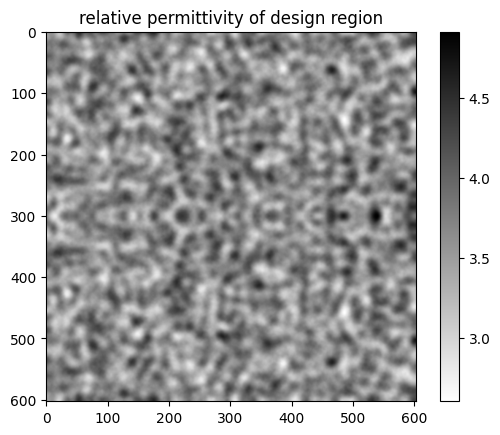

In [15]:
eps_arr = structure.medium.permittivity.values
im = plt.imshow(eps_arr.squeeze().T, cmap="binary")
plt.colorbar(im)
plt.title("relative permittivity of design region")
plt.show()

## Inverse Design Object

In [16]:
design = tdi.InverseDesign(
    simulation=sim,
    design_region=design_region,
    task_name="invdes",
    output_monitor_names= [mnt.name for mnt in output_monitors],
)

In [17]:
params0 = 0.5 * np.ones_like(params0)

sim = design.to_simulation(params=params0)
ax = sim.plot_3d(800, 800)

## Multi-Simulation Objective

In [18]:
# create a simulation for each of the independent sources
simulations = [
    sim.updated_copy(sources=[source_list[i]], monitors=[output_monitors[i]]) for i in range(len(source_list))
]

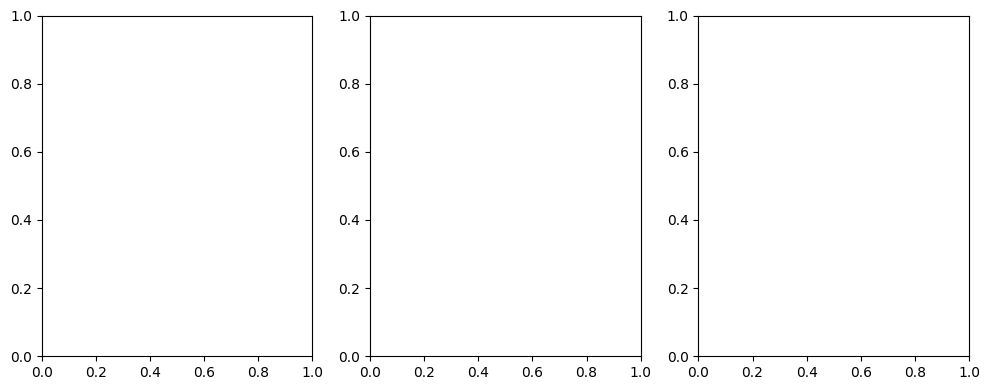

In [19]:
f, axes = plt.subplots(1, 3, figsize=(10, 4), tight_layout=True)
for ax, sim in zip(axes, simulations):
    sim.plot_3d()

In [20]:
output_monitor_names = [[monitor.name] for monitor in output_monitors]

def post_process_fn(batch_data: dict[str, td.SimulationData]) -> float:
    """Grab the power going at the monitor in the xy plane"""
    power_diffracted = 0.0
    for (task_name, sim_data), output_mnt_list in zip(batch_data.items(), output_monitor_names):
        output_mnt_name = output_mnt_list[0]
        amps = tdi.utils.get_amps(sim_data, monitor_name=output_mnt_name, direction="+")
        power = tdi.utils.sum_abs_squared(amps)

        # # or, when written in more low-level syntax
        # amp = sim_data[mnt_name_left].amps.sel(direction="-")
        # power = abs(jnp.sum(jnp.array(amp.values)))**2

        power_diffracted += power
    return power_diffracted



In [21]:
# define multi design object

design_multi = tdi.InverseDesignMulti(
    design_region=design_region,
    simulations=simulations,
    task_name="invdes_multi",
    output_monitor_names=output_monitor_names,
    verbose=True,
)

print(output_monitor_names)

[['output_monitor0'], ['output_monitor1'], ['output_monitor2']]


In [22]:
# define optimizer
# MAKE SURE results_cache_fname parameter is filled out, or else simulation results won't save, see the call to results = tdi.InverseDesignResult.from_file(optimizer.results_cache_fname)
# to see how you can load old sim results from a file
optimizer = tdi.AdamOptimizer(
    design=design_multi,
    learning_rate=0.12,
    results_cache_fname="data/invdes_design_multi.hdf5",
    num_steps=25,
)

In [23]:
simulations_dict = design_multi.to_simulation(params=params0)
print(len(simulations_dict))
total_cost = 0.0
for simulation in simulations_dict.items():
    job = web.Job(simulation=simulation[1], task_name="job")
    total_cost += web.estimate_cost(job.task_id)

print(f"Total cost is {total_cost}")
    

3


15:42:15 PST Created task 'job' with resource_id                                
             'fdve-ca1f8466-93b6-4734-8e64-ea04ab8f7169' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=619512;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ca1f8466-93b6-4734-8e64-ea04ab8f7169\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=948092;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ca1f8466-93b6-4734-8e64-ea04ab8f7169\taskId]8;;\]8;id=619512;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ca1f8466-93b6-4734-8e64-ea04ab8f7169\=]8;;\]8;id=593616;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ca1f8466-93b6-4734-8e64-ea04ab8f7169\fdve]8;;\]8;id=619512;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ca1f8466-93b6-4734-8e64-ea04ab8f7169\-ca1f8466-93b]8;;\
             ]8;id=619512;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ca1f8466-93b6-4734-8e64-ea04ab8f7169\6-4734-8e64-ea04ab8f7169']8;;\.

             Task folder: ]8;id=3873;https://tidy3d.simulation.cloud/folders/folder-c1256dcf-ea12-4d61-b02e-44feec7479e6\'default']8;;\.

Output()

...

             Task folder: ]8;id=195855;https://tidy3d.simulation.cloud/folders/folder-c1256dcf-ea12-4d61-b02e-44feec7479e6\'default']8;;\.

Output()

15:42:26 PST Estimated FlexCredit cost: 4.046. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

             Estimated FlexCredit cost: 4.046. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

Total cost is 12.137443446695244


In [ ]:
results = optimizer.run(post_process_fn=post_process_fn, params0=params0)


15:44:28 PST WARNING: The 'params0' argument is deprecated and will be removed  
             in the future. Please use a 'DesignRegion.initialization_spec' in  
             the design region to specify initial parameters instead. For now,  
             'params0' will take precedence over 'initialization_spec'.         

Output()

Output()

Output()

Output()

...

15:49:24 PST Batch complete.

15:49:31 PST Started working on Batch containing 3 tasks.

15:49:37 PST Maximum FlexCredit cost: 12.248 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

In [ ]:
results.plot_optimization()

In [ ]:
#sim_data_last = results.sim_data_last()
sim_last = results.sim_last
# BECAUSE I USED 3 SIMS THE CALL TO .sim_last RETURNS A DICTIONARY OF 3 SIMULATIONS, YOU NEED TO PICK A NAME OF ONE OF THE SIMS
#print(type(sim_last[0]))
print("Keys for the simulation names in the dictionary sim_last are " + str(sim_last.keys()))
ax = sim_last["invdes_multi_0"].plot_eps(z=0.1, monitor_alpha=0.0, source_alpha=0.0)
ax = sim_last["invdes_multi_1"].plot_eps(z=0.1, monitor_alpha=0.0, source_alpha=0.0)
ax = sim_last["invdes_multi_2"].plot_eps(z=0.1, monitor_alpha=0.0, source_alpha=0.0)

In [ ]:
sim_last["invdes_multi_2"].to_gds_file(
    fname="generated_files/inv_des_initial.gds", z=0, frequency=freq0, permittivity_threshold=2.5
)

In [ ]:

job = web.Job(simulation=sim_last, task_name="inv_des_final")
estimated_cost = web.estimate_cost(job.task_id)
sim_data_final = job.run(path="data/first_migc_sim.hdf5")